In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [9]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [10]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [11]:
X_pima = pima_df[pima_cols[:-1]].copy()

In [12]:
y_pima = pima_df['Outcome']

In [17]:
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [18]:
X_pima[cols_to_impute] = X_pima[cols_to_impute].replace(0, np.nan)

In [20]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

In [21]:
imputer = SimpleImputer(strategy='median')

In [22]:
X_imputed = imputer.fit_transform(X_pima)

In [23]:
scaler = StandardScaler()

In [24]:
X_pima_scaled = scaler.fit_transform(X_imputed)

In [25]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima_scaled, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [26]:
print("Preprocessed Pima dataset shapes:")

Preprocessed Pima dataset shapes:


In [27]:
print(f"  Training set features: {X_train_p.shape} | Test set features: {X_test_p.shape}")

  Training set features: (614, 8) | Test set features: (154, 8)


In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann_pima = Sequential([

    Dense(16, activation='relu', input_shape=(8,)),

    Dense(8, activation='relu'),

    Dense(1, activation='sigmoid')
])

print("Sequential ANN Architecture established:")
ann_pima.summary()


Sequential ANN Architecture established:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
ann_pima.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
print("Neural network model compiled successfully.")

Neural network model compiled successfully.


In [31]:

history_pima = ann_pima.fit(
    X_train_p,
    y_train_p,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print("\nModel training complete.")


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6538 - loss: 0.6878 - val_accuracy: 0.6423 - val_loss: 0.7028
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6538 - loss: 0.6319 - val_accuracy: 0.6423 - val_loss: 0.6414
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6578 - loss: 0.5887 - val_accuracy: 0.6504 - val_loss: 0.6000
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6802 - loss: 0.5557 - val_accuracy: 0.6667 - val_loss: 0.5637
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6945 - loss: 0.5299 - val_accuracy: 0.6992 - val_loss: 0.5374
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7271 - loss: 0.5090 - val_accuracy: 0.6911 - val_loss: 0.5200
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7454 - loss: 0.4944 - val_accuracy: 0.7236 - val_loss: 0.5037
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7597 - loss: 0.4829 - val_accuracy: 0.7398 - val_loss

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
ANN Holdout Test Accuracy: 77.92%

--- Classification Report ---
              precision    recall  f1-score   support

 No Diabetes       0.82      0.84      0.83       100
    Diabetes       0.69      0.67      0.68        54

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.76       154
weighted avg       0.78      0.78      0.78       154



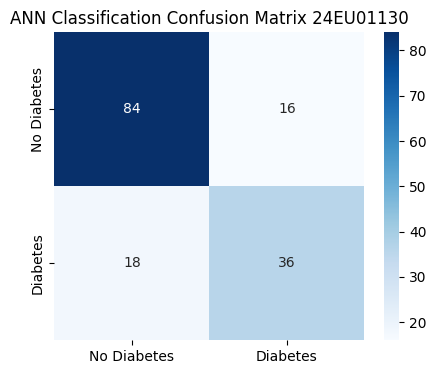

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = ann_pima.predict(X_test_p)
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

test_acc = accuracy_score(y_test_p, y_pred_classes)
print(f"ANN Holdout Test Accuracy: {test_acc * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test_p, y_pred_classes, target_names=['No Diabetes', 'Diabetes']))


cm_pima = confusion_matrix(y_test_p, y_pred_classes)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pima, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("ANN Classification Confusion Matrix 24EU01130")
plt.show()


In [34]:
import warnings

In [35]:
warnings.filterwarnings("ignore")

In [36]:
import pandas as pd

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [40]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [41]:
sonar_columns = sonar_features + ['Class']

In [42]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [43]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [44]:
X_sonar = sonar_df[sonar_features]

In [45]:
y_sonar = sonar_df['Class_numeric']

In [46]:
scaler_sonar = StandardScaler()

In [47]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [48]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)


In [49]:
print("Sonar Training Set Shape:", X_train_s.shape)

Sonar Training Set Shape: (145, 60)


In [50]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


ann_sonar = Sequential([

    Dense(64, activation='relu', input_shape=(60,)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

print("Regularized Sonar ANN Architecture established:")
ann_sonar.summary()


Regularized Sonar ANN Architecture established:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:

ann_sonar.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history_sonar = ann_sonar.fit(
    X_train_s,
    y_train_s,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print("\nModel training complete.")


Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.5086 - loss: 0.8225 - val_accuracy: 0.6207 - val_loss: 0.6740
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5776 - loss: 0.7043 - val_accuracy: 0.6552 - val_loss: 0.6335
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5431 - loss: 0.7341 - val_accuracy: 0.6897 - val_loss: 0.5939
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6897 - loss: 0.5908 - val_accuracy: 0.6207 - val_loss: 0.5703
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6724 - loss: 0.5974 - val_accuracy: 0.6552 - val_loss: 0.5501
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7500 - loss: 0.5525 - val_accuracy: 0.6552 - val_loss: 0.5287
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7500 - loss: 0.5219 - val_accuracy: 0.6552 - val_loss: 0.5144
Epoch 8/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7845 - loss: 0.4596 - val_accuracy: 0.6552 - val_loss: 0.5007


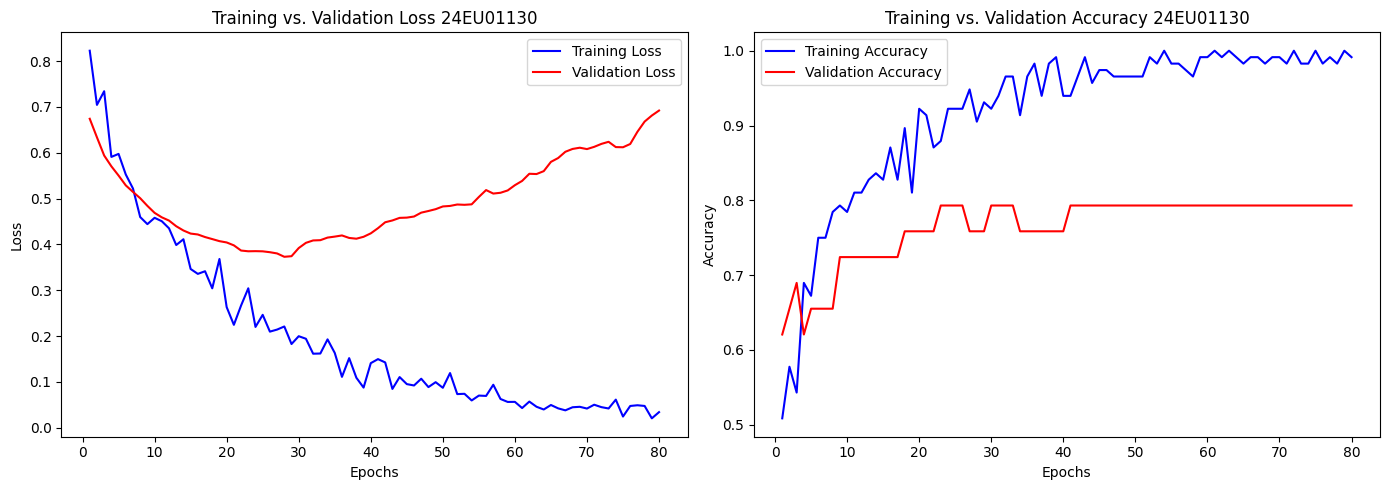

In [53]:
import matplotlib.pyplot as plt

# Extract metrics from training history
train_loss = history_sonar.history['loss']
val_loss = history_sonar.history['val_loss']
train_acc = history_sonar.history['accuracy']
val_acc = history_sonar.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_loss, 'b-', label='Training Loss')
axes[0].plot(epochs_range, val_loss, 'r-', label='Validation Loss')
axes[0].set_title("Training vs. Validation Loss 24EU01130")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot accuracy curves
axes[1].plot(epochs_range, train_acc, 'b-', label='Training Accuracy')
axes[1].plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
axes[1].set_title("Training vs. Validation Accuracy 24EU01130")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
--- Classification Report (Sonar Test Set) ---
              precision    recall  f1-score   support

    Rock (0)       0.83      0.86      0.85        29
    Mine (1)       0.88      0.85      0.87        34

    accuracy                           0.86        63
   macro avg       0.86      0.86      0.86        63
weighted avg       0.86      0.86      0.86        63



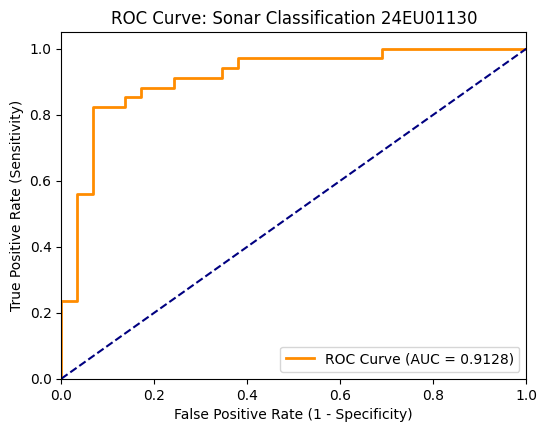

In [54]:
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

sonar_probs = ann_sonar.predict(X_test_s)[:, 0]
sonar_preds = (sonar_probs >= 0.5).astype(int)

print("--- Classification Report (Sonar Test Set) ---")
print(classification_report(y_test_s, sonar_preds, target_names=['Rock (0)', 'Mine (1)']))

fpr, tpr, _ = roc_curve(y_test_s, sonar_probs)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("ROC Curve: Sonar Classification 24EU01130")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.show()


In [55]:
import tensorflow as tf

In [56]:
from tensorflow.keras.models import Sequential

In [59]:
from tensorflow.keras.layers import Dense

In [75]:
def build_ann_model(optimizer_name='adam'):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(8,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizer_name,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [63]:
 model = Sequential([
        Dense(32, activation='relu', input_shape=(8,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

In [65]:
optimizer_name = 'adam'
model.compile(
        optimizer=optimizer_name,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

In [67]:
print("Modular ANN model builder function established.")

Modular ANN model builder function established.


In [68]:
optimizers = ['adam', 'sgd', 'rmsprop']

In [69]:
history_records = {}

In [70]:
print("--- Running Optimizer Search ---")

--- Running Optimizer Search ---


In [77]:
for opt in optimizers:
    print(f"Training network using: {opt}...")
    temp_model = build_ann_model(optimizer_name=opt)
    hist = temp_model.fit(
        X_train_p,
        y_train_p,
        validation_split=0.2,
        epochs=30,
        batch_size=16,
        verbose=0
    )
    history_records[opt] = hist.history['val_loss']

Training network using: adam...
Training network using: sgd...
Training network using: rmsprop...


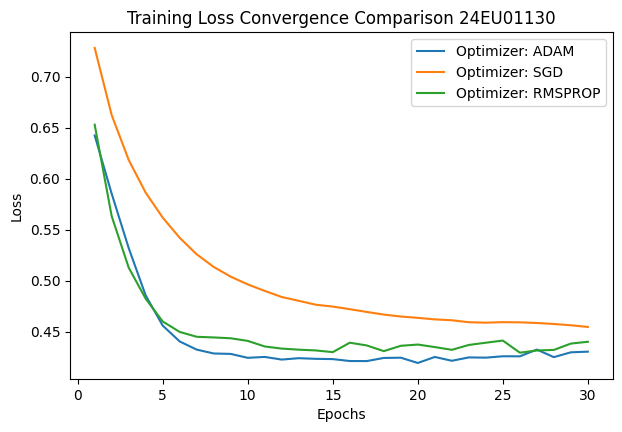

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4.5))
for opt in optimizers:
    plt.plot(range(1, 31), history_records[opt], label=f"Optimizer: {opt.upper()}")

plt.title("Training Loss Convergence Comparison 24EU01130")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [79]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

tuned_model = build_ann_model(optimizer_name='adam')

print("Training model with Early Stopping...")
history_tuned = tuned_model.fit(
    X_train_p,
    y_train_p,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Training model with Early Stopping...
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6415 - loss: 0.6836 - val_accuracy: 0.6748 - val_loss: 0.6606
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7556 - loss: 0.6150 - val_accuracy: 0.7317 - val_loss: 0.5988
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7597 - loss: 0.5615 - val_accuracy: 0.7805 - val_loss: 0.5393
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7739 - loss: 0.5172 - val_accuracy: 0.7724 - val_loss: 0.4976
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7739 - loss: 0.4844 - val_accuracy: 0.7642 - val_loss: 0.4724
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7699 - loss: 0.4642 - val_accuracy: 0.7724 - val_loss: 0.4553
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7821 - loss: 0.4526 - val_accuracy: 0.7724 - val_loss: 0.4453
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7882

In [80]:
from sklearn.metrics import accuracy_score

In [81]:
baseline_accuracy = ann_pima.evaluate(X_test_p, y_test_p, verbose=0)[1]

In [82]:
tuned_accuracy = tuned_model.evaluate(X_test_p, y_test_p, verbose=0)[1]


In [84]:
comparison_df = pd.DataFrame({
    'Model Configuration': ['Baseline ANN (Fixed 50 Epochs)', 'Tuned ANN (with Early Stopping)'],
    'Test Accuracy (%)': [baseline_accuracy * 100, tuned_accuracy * 100],
    'Epochs Trained': [50, len(history_tuned.history['loss'])]
})

In [85]:
print("--- Final Performance Comparison ---")

--- Final Performance Comparison ---


In [86]:
print(comparison_df.to_string(index=False))

            Model Configuration  Test Accuracy (%)  Epochs Trained
 Baseline ANN (Fixed 50 Epochs)          77.922076              50
Tuned ANN (with Early Stopping)          74.025977              26
